<a href="https://colab.research.google.com/github/Nausheen1295/NorthStar-Coursework/blob/main/notebooks/Section_1_R/02_r_analytics.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [1]:
install.packages("dplyr")
install.packages("ggplot2")
install.packages("lubridate")

library(dplyr)
library(ggplot2)
library(lubridate)

Installing package into ‘/usr/local/lib/R/site-library’
(as ‘lib’ is unspecified)

Installing package into ‘/usr/local/lib/R/site-library’
(as ‘lib’ is unspecified)

Installing package into ‘/usr/local/lib/R/site-library’
(as ‘lib’ is unspecified)


Attaching package: ‘dplyr’


The following objects are masked from ‘package:stats’:

    filter, lag


The following objects are masked from ‘package:base’:

    intersect, setdiff, setequal, union



Attaching package: ‘lubridate’


The following objects are masked from ‘package:base’:

    date, intersect, setdiff, union




In [2]:
list.files("/content")

[1] "app_events.csv"      "complaints.csv"      "customers.csv"      
 [4] "data_dictionary.csv" "deliveries.csv"      "drivers.csv"        
 [7] "hubs.csv"            "incidents.csv"       "orders.csv"         
[10] "README.txt"          "sample_data"         "vehicles.csv"

In [3]:
orders <- read.csv("/content/orders.csv")
deliveries <- read.csv("/content/deliveries.csv")
customers <- read.csv("/content/customers.csv")
drivers <- read.csv("/content/drivers.csv")
vehicles <- read.csv("/content/vehicles.csv")
hubs <- read.csv("/content/hubs.csv")
complaints <- read.csv("/content/complaints.csv")
incidents <- read.csv("/content/incidents.csv")
app_events <- read.csv("/content/app_events.csv")

In [4]:
# Create complaint summary by order
complaint_summary <- complaints %>%
  group_by(order_id) %>%
  summarise(
    complaint_count = n(),
    total_compensation = sum(compensation_amount, na.rm = TRUE),
    avg_resolution_days = mean(resolution_days, na.rm = TRUE)
  )

# Create incident summary by delivery
incident_summary <- incidents %>%
  group_by(delivery_id) %>%
  summarise(
    incident_count = n(),
    high_incident_count = sum(severity == "High", na.rm = TRUE),
    avg_resolved_hours = mean(resolved_hours, na.rm = TRUE)
  )

# Join tables to create master dataset
master <- orders %>%
  left_join(deliveries, by = "order_id") %>%
  left_join(customers, by = "customer_id") %>%
  left_join(hubs, by = "hub_id") %>%
  left_join(drivers, by = "driver_id") %>%
  left_join(vehicles, by = "vehicle_id") %>%
  left_join(complaint_summary, by = "order_id") %>%
  left_join(incident_summary, by = "delivery_id")

head(master)

,order_id,customer_id,service_type,order_created_at,promised_window_hours,pickup_zone,dropoff_zone,priority_level,order_value,booking_channel,⋯,battery_health_pct,odometer_km,maintenance_status,telematics_version,complaint_count,total_compensation,avg_resolution_days,incident_count,high_incident_count,avg_resolved_hours
,<chr>,<chr>,<chr>,<chr>,<int>,<chr>,<chr>,<chr>,<dbl>,<chr>,⋯,<dbl>,<int>,<chr>,<chr>,<int>,<dbl>,<dbl>,<int>,<int>,<dbl>
1,O00001,C0292,Passenger,2024-08-20 14:43:00,6,Airport,South,Medium,126.65,App,⋯,93.8,98472,InRepair,v2.0,NA,NA,NA,NA,NA,NA
2,O00002,C0459,Passenger,2024-05-14 22:16:00,24,North,AIRPORT,Low,109.30,App,⋯,NA,NA,NA,NA,NA,NA,NA,NA,NA,NA
3,O00003,C0161,Passenger,2025-09-02 14:37:00,4,West,AIRPORT,High,33.50,Phone,⋯,60.1,31876,Active,v2.0,1,8.66,2,NA,NA,NA
4,O00004,C0520,Parcel,2025-01-11 17:15:00,2,RiverSide,North,Medium,10.04,App,⋯,68.6,78468,Active,v2.2,NA,NA,NA,NA,NA,NA
5,O00005,C0558,Retail,2025-02-17 19:32:00,12,Riverside,SOUTH,Low,125.58,Phone,⋯,NA,191353,Active,v2.1,1,54.41,8,NA,NA,NA
6,O00006,C0437,Retail,2024-08-05 04:55:00,1,CENTRAL,East,High,151.44,Web,⋯,NA,NA,NA,NA,NA,NA,NA,NA,NA,NA


In [5]:
# Replace missing complaint and incident values with zero
master$complaint_count[is.na(master$complaint_count)] <- 0
master$total_compensation[is.na(master$total_compensation)] <- 0
master$incident_count[is.na(master$incident_count)] <- 0
master$high_incident_count[is.na(master$high_incident_count)] <- 0

In [6]:
# Convert date and time columns
master$dispatch_time <- ymd_hms(master$dispatch_time)
master$delivery_completed_at <- ymd_hms(master$delivery_completed_at)

# Calculate delivery duration in hours
master$delivery_duration_hours <- as.numeric(
  difftime(master$delivery_completed_at, master$dispatch_time, units = "hours")
)

# Create failed delivery flag
master$failed_flag <- ifelse(master$delivery_status == "Failed", 1, 0)

# Create late delivery flag
master$late_flag <- ifelse(
  master$delivery_duration_hours > master$promised_window_hours,
  1,
  0
)

# Estimate profit
master$estimated_profit <- master$order_value - master$fuel_or_charge_cost

# Create low rating flag
master$low_rating_flag <- ifelse(master$customer_rating_post_delivery < 3, 1, 0)

head(master)

,order_id,customer_id,service_type,order_created_at,promised_window_hours,pickup_zone,dropoff_zone,priority_level,order_value,booking_channel,⋯,total_compensation,avg_resolution_days,incident_count,high_incident_count,avg_resolved_hours,delivery_duration_hours,failed_flag,late_flag,estimated_profit,low_rating_flag
,<chr>,<chr>,<chr>,<chr>,<int>,<chr>,<chr>,<chr>,<dbl>,<chr>,⋯,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>
1,O00001,C0292,Passenger,2024-08-20 14:43:00,6,Airport,South,Medium,126.65,App,⋯,0.00,NA,0,0,NA,2.398937,0,0,110.83,0
2,O00002,C0459,Passenger,2024-05-14 22:16:00,24,North,AIRPORT,Low,109.30,App,⋯,0.00,NA,0,0,NA,NA,NA,NA,NA,NA
3,O00003,C0161,Passenger,2025-09-02 14:37:00,4,West,AIRPORT,High,33.50,Phone,⋯,8.66,2,0,0,NA,8.861012,0,1,20.34,0
4,O00004,C0520,Parcel,2025-01-11 17:15:00,2,RiverSide,North,Medium,10.04,App,⋯,0.00,NA,0,0,NA,-1.100000,0,0,-3.37,0
5,O00005,C0558,Retail,2025-02-17 19:32:00,12,Riverside,SOUTH,Low,125.58,Phone,⋯,54.41,8,0,0,NA,11.700013,0,0,112.05,0
6,O00006,C0437,Retail,2024-08-05 04:55:00,1,CENTRAL,East,High,151.44,Web,⋯,0.00,NA,0,0,NA,NA,NA,NA,NA,NA


In [7]:
# Select only failed deliveries
failed_deliveries <- master %>%
  filter(delivery_status == "Failed")

head(failed_deliveries)

,order_id,customer_id,service_type,order_created_at,promised_window_hours,pickup_zone,dropoff_zone,priority_level,order_value,booking_channel,⋯,total_compensation,avg_resolution_days,incident_count,high_incident_count,avg_resolved_hours,delivery_duration_hours,failed_flag,late_flag,estimated_profit,low_rating_flag
,<chr>,<chr>,<chr>,<chr>,<int>,<chr>,<chr>,<chr>,<dbl>,<chr>,⋯,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>
1,O00023,C0077,Passenger,2025-10-05 04:59:00,4,north,north,Medium,122.25,App,⋯,0.00,7,0,0,NA,22.440958,1,1,111.38,1
2,O00031,C0573,Passenger,2024-10-25 03:17:00,24,EAST,AIRPORT,Medium,55.14,App,⋯,78.33,7,0,0,NA,28.589133,1,1,45.86,1
3,O00033,C0471,Retail,2025-12-30 21:02:00,6,NORTH,East,Low,36.70,Phone,⋯,0.00,NA,0,0,NA,16.980866,1,1,19.90,0
4,O00035,C0524,Business,2024-06-14 13:12:00,4,north,CENTRAL,Medium,209.07,Web,⋯,0.00,NA,0,0,NA,14.029728,1,1,199.87,1
5,O00070,C0125,Retail,2025-05-13 21:30:00,4,Ctr,AIRPORT,Low,165.63,App,⋯,0.00,NA,1,1,33.9,16.553904,1,1,157.70,1
6,O00071,C0109,Medical,2024-08-31 22:15:00,1,North,SOUTH,Low,157.58,Phone,⋯,18.13,10,0,0,NA,1.340644,1,1,152.35,0


In [8]:
# Select useful columns for operational analysis
service_analysis <- master %>%
  select(
    order_id,
    service_type,
    pickup_zone,
    dropoff_zone,
    delivery_status,
    customer_rating_post_delivery,
    complaint_count,
    incident_count,
    manual_route_override_count,
    estimated_profit
  )

head(service_analysis)

,order_id,service_type,pickup_zone,dropoff_zone,delivery_status,customer_rating_post_delivery,complaint_count,incident_count,manual_route_override_count,estimated_profit
,<chr>,<chr>,<chr>,<chr>,<chr>,<dbl>,<dbl>,<dbl>,<int>,<dbl>
1,O00001,Passenger,Airport,South,OnTime,4.29,0,0,2,110.83
2,O00002,Passenger,North,AIRPORT,NA,NA,0,0,NA,NA
3,O00003,Passenger,West,AIRPORT,Delayed,3.70,1,0,2,20.34
4,O00004,Parcel,RiverSide,North,OnTime,5.00,0,0,1,-3.37
5,O00005,Retail,Riverside,SOUTH,OnTime,4.38,1,0,1,112.05
6,O00006,Retail,CENTRAL,East,NA,NA,0,0,NA,NA


In [9]:
# Arrange orders by highest complaint count
highest_complaints <- master %>%
  arrange(desc(complaint_count))

head(highest_complaints)

,order_id,customer_id,service_type,order_created_at,promised_window_hours,pickup_zone,dropoff_zone,priority_level,order_value,booking_channel,⋯,total_compensation,avg_resolution_days,incident_count,high_incident_count,avg_resolved_hours,delivery_duration_hours,failed_flag,late_flag,estimated_profit,low_rating_flag
,<chr>,<chr>,<chr>,<chr>,<int>,<chr>,<chr>,<chr>,<dbl>,<chr>,⋯,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>
1,O00125,C0191,Retail,2025-09-17 16:27:00,24,West,South,Medium,70.05,App,⋯,62.76,6.333333,0,0,NA,NA,NA,NA,NA,NA
2,O00795,C0142,Retail,2025-06-15 13:49:00,2,Riverside,CENTRAL,Medium,42.52,App,⋯,59.14,10.333333,0,0,NA,NA,NA,NA,NA,NA
3,O00031,C0573,Passenger,2024-10-25 03:17:00,24,EAST,AIRPORT,Medium,55.14,App,⋯,78.33,7.000000,0,0,NA,28.589133,1,1,45.86,1
4,O00167,C0325,Medical,2024-04-27 20:46:00,24,East,EAST,Medium,24.78,API,⋯,33.06,4.000000,0,0,NA,22.545555,0,0,6.24,0
5,O00190,C0622,Parcel,2024-12-28 06:44:00,1,South,north,Medium,31.72,Phone,⋯,18.19,12.000000,0,0,NA,-1.533333,0,0,21.14,0
6,O00219,C0421,Passenger,2024-05-29 23:42:00,2,East,South,Medium,62.84,App,⋯,73.13,11.000000,0,0,NA,1.715118,0,0,55.85,0


In [10]:
# Summarise performance by service type
service_summary <- master %>%
  group_by(service_type) %>%
  summarise(
    total_orders = n(),
    failed_deliveries = sum(failed_flag, na.rm = TRUE),
    failure_rate = mean(failed_flag, na.rm = TRUE),
    avg_rating = mean(customer_rating_post_delivery, na.rm = TRUE),
    total_complaints = sum(complaint_count, na.rm = TRUE),
    total_profit = sum(estimated_profit, na.rm = TRUE)
  ) %>%
  arrange(desc(failure_rate))

service_summary

service_type,total_orders,failed_deliveries,failure_rate,avg_rating,total_complaints,total_profit
<chr>,<int>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>
Business,165,25,0.1984127,3.847280,39,10623.32
Medical,139,16,0.1481481,3.837685,37,7965.40
Passenger,341,38,0.1450382,3.845253,84,22214.80
Retail,297,28,0.1250000,3.872545,83,16538.59
Parcel,308,25,0.1086957,3.901637,77,17726.43


In [11]:
# Summarise performance by zone
zone_summary <- master %>%
  group_by(zone) %>%
  summarise(
    total_deliveries = n(),
    failed_deliveries = sum(failed_flag, na.rm = TRUE),
    failure_rate = mean(failed_flag, na.rm = TRUE),
    avg_rating = mean(customer_rating_post_delivery, na.rm = TRUE),
    avg_overrides = mean(manual_route_override_count, na.rm = TRUE),
    total_complaints = sum(complaint_count, na.rm = TRUE)
  ) %>%
  arrange(desc(failure_rate))

zone_summary

zone,total_deliveries,failed_deliveries,failure_rate,avg_rating,avg_overrides,total_complaints
<chr>,<int>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>
Central,243,49,0.20164609,3.782479,1.0329218,65
Airport,104,15,0.14423077,3.882136,0.9134615,23
West,127,16,0.12598425,3.915476,0.8740157,28
North,136,17,0.12500000,3.840593,1.0294118,32
Riverside,115,14,0.12173913,3.881858,1.0521739,33
South,106,10,0.09433962,3.950952,0.9150943,18
East,119,11,0.09243697,3.895862,0.8907563,33
NA,300,0,NaN,NaN,NaN,88


In [12]:
library(ggplot2)

Warning message:
“Removed 1 row containing missing values or values outside the scale range
(`geom_bar()`).”


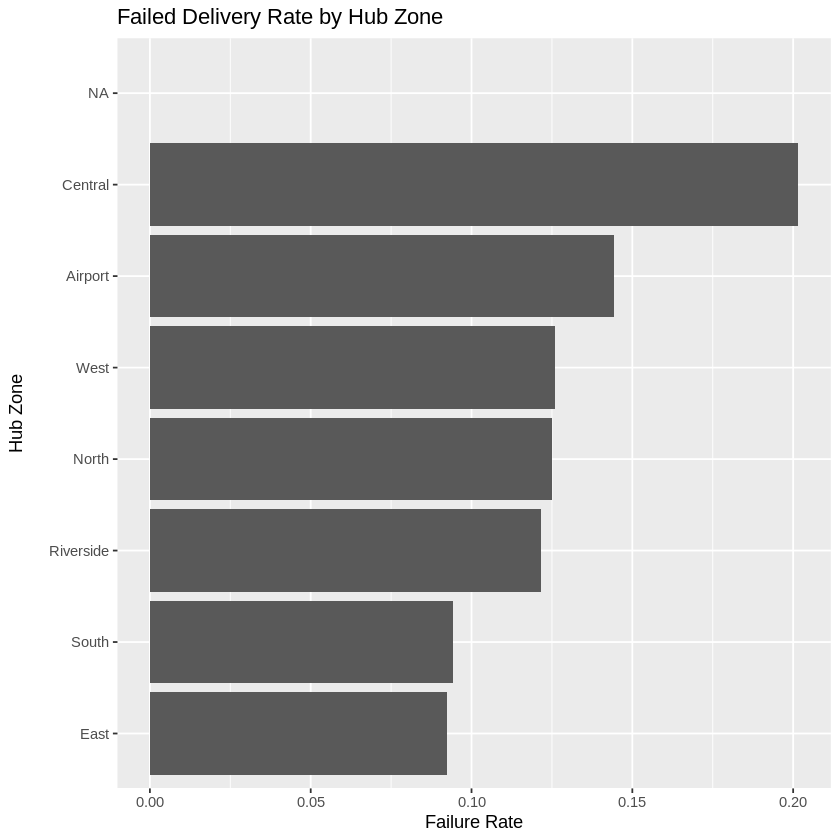

In [13]:
#Bar chart — Failed delivery rate by zone
ggplot(zone_summary, aes(x = reorder(zone, failure_rate), y = failure_rate)) +
  geom_bar(stat = "identity") +
  coord_flip() +
  labs(
    title = "Failed Delivery Rate by Hub Zone",
    x = "Hub Zone",
    y = "Failure Rate"
  )

Warning message:
“Removed 314 rows containing missing values or values outside the scale range
(`geom_point()`).”


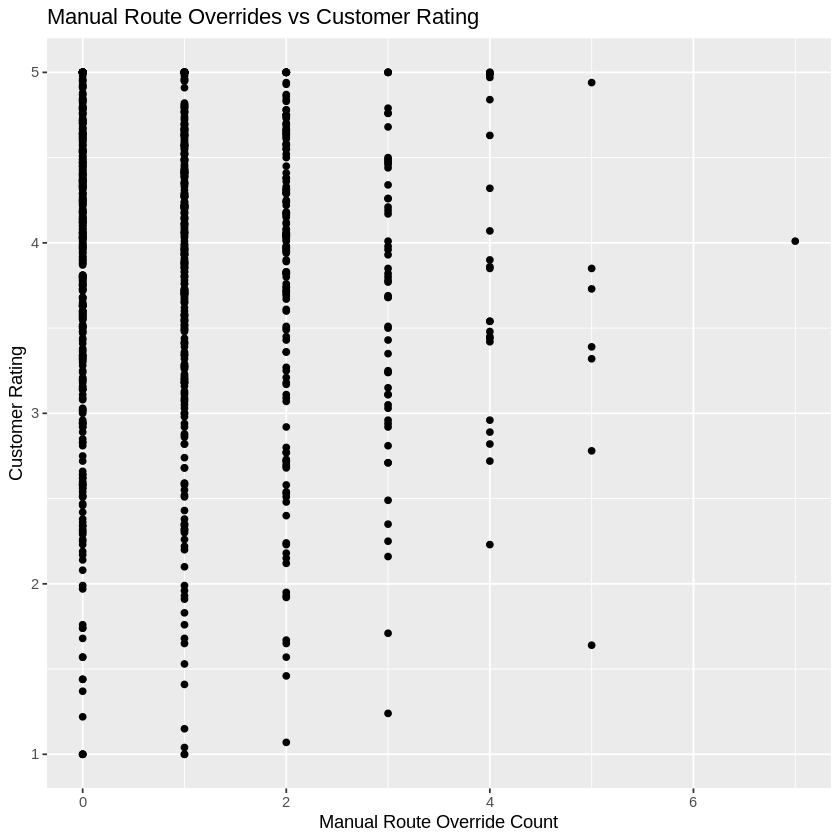

In [14]:
#Scatter plot — Route overrides vs customer rating
ggplot(master, aes(x = manual_route_override_count, y = customer_rating_post_delivery)) +
  geom_point() +
  labs(
    title = "Manual Route Overrides vs Customer Rating",
    x = "Manual Route Override Count",
    y = "Customer Rating"
  )

Warning message:
“Removed 314 rows containing missing values or values outside the scale range
(`geom_point()`).”


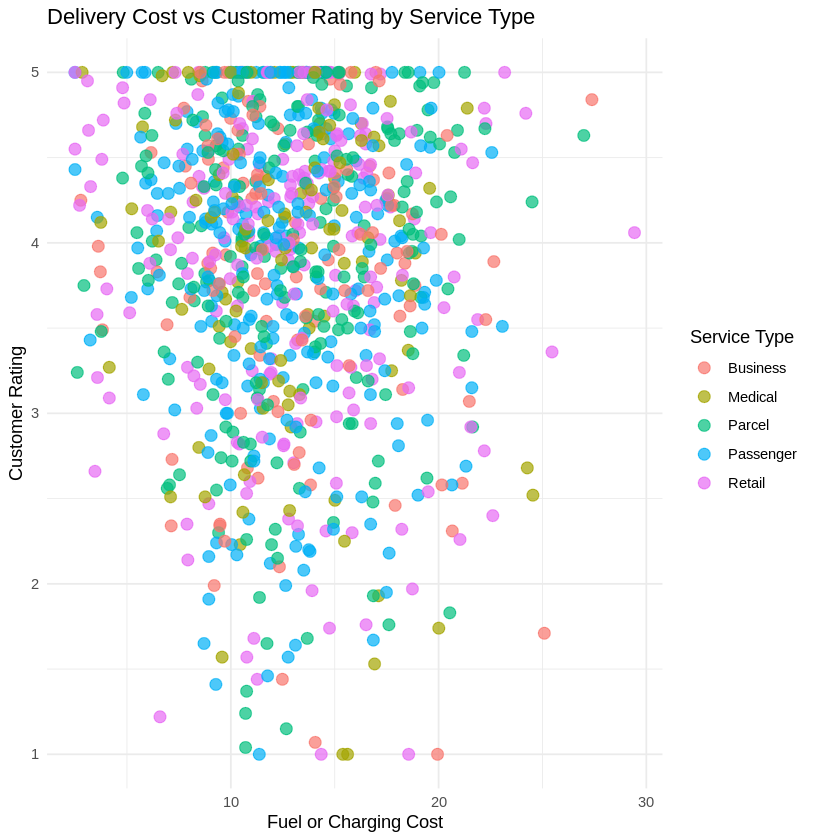

In [15]:
# Colourful scatterplot: Delivery cost vs customer rating by service type

ggplot(master, aes(
  x = fuel_or_charge_cost,
  y = customer_rating_post_delivery,
  color = service_type
)) +
  geom_point(size = 3, alpha = 0.7) +
  labs(
    title = "Delivery Cost vs Customer Rating by Service Type",
    x = "Fuel or Charging Cost",
    y = "Customer Rating",
    color = "Service Type"
  ) +
  theme_minimal()

`summarise()` has regrouped the output.
ℹ Summaries were computed grouped by driver_id, training_score, and base_zone.
ℹ Output is grouped by driver_id and training_score.
ℹ Use `summarise(.groups = "drop_last")` to silence this message.
ℹ Use `summarise(.by = c(driver_id, training_score, base_zone))` for
  per-operation grouping (`?dplyr::dplyr_by`) instead.
Warning message:
“Removed 7 rows containing missing values or values outside the scale range
(`geom_point()`).”


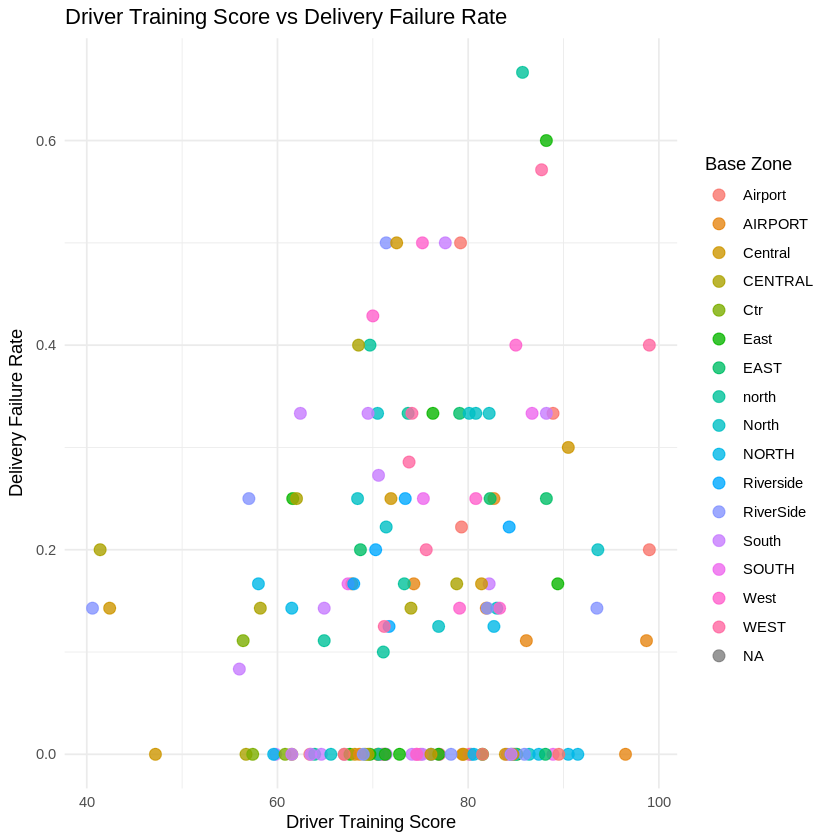

In [16]:
# Create driver-level failure rate summary

driver_scatter <- master %>%
  group_by(driver_id, training_score, base_zone) %>%
  summarise(
    total_deliveries = n(),
    failed_deliveries = sum(failed_flag, na.rm = TRUE),
    failure_rate = failed_deliveries / total_deliveries
  ) %>%
  filter(total_deliveries >= 3)

# Colourful scatterplot: Training score vs failure rate by base zone

ggplot(driver_scatter, aes(
  x = training_score,
  y = failure_rate,
  color = base_zone
)) +
  geom_point(size = 3, alpha = 0.8) +
  labs(
    title = "Driver Training Score vs Delivery Failure Rate",
    x = "Driver Training Score",
    y = "Delivery Failure Rate",
    color = "Base Zone"
  ) +
  theme_minimal()

Warning message:
“Removed 314 rows containing non-finite outside the scale range
(`stat_boxplot()`).”


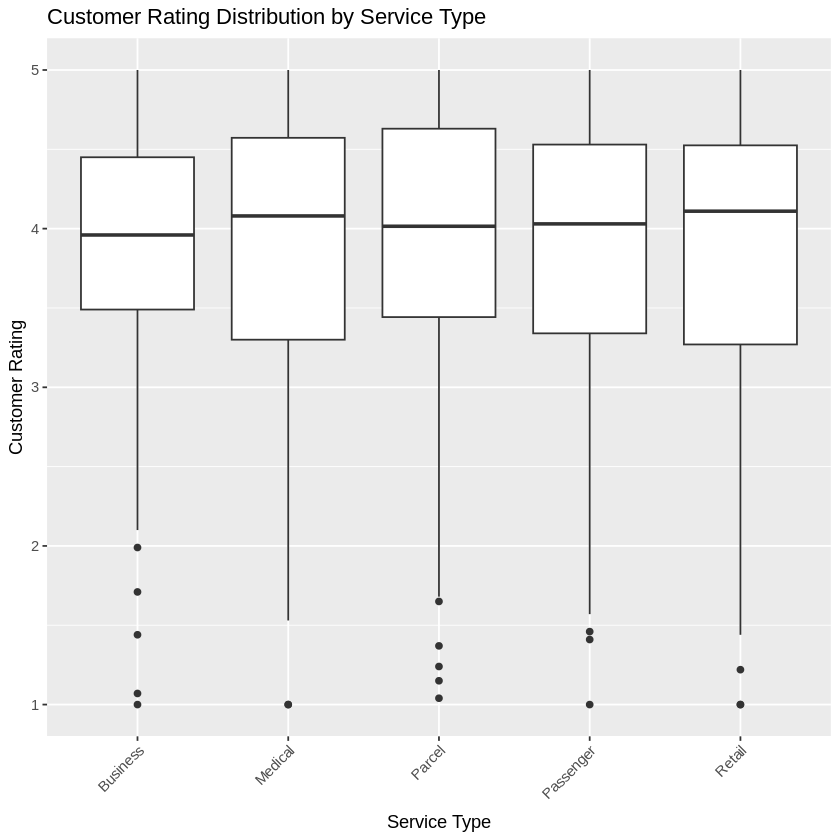

In [17]:
#Boxplot — Customer rating by service type
ggplot(master, aes(x = service_type, y = customer_rating_post_delivery)) +
  geom_boxplot() +
  labs(
    title = "Customer Rating Distribution by Service Type",
    x = "Service Type",
    y = "Customer Rating"
  ) +
  theme(axis.text.x = element_text(angle = 45, hjust = 1))

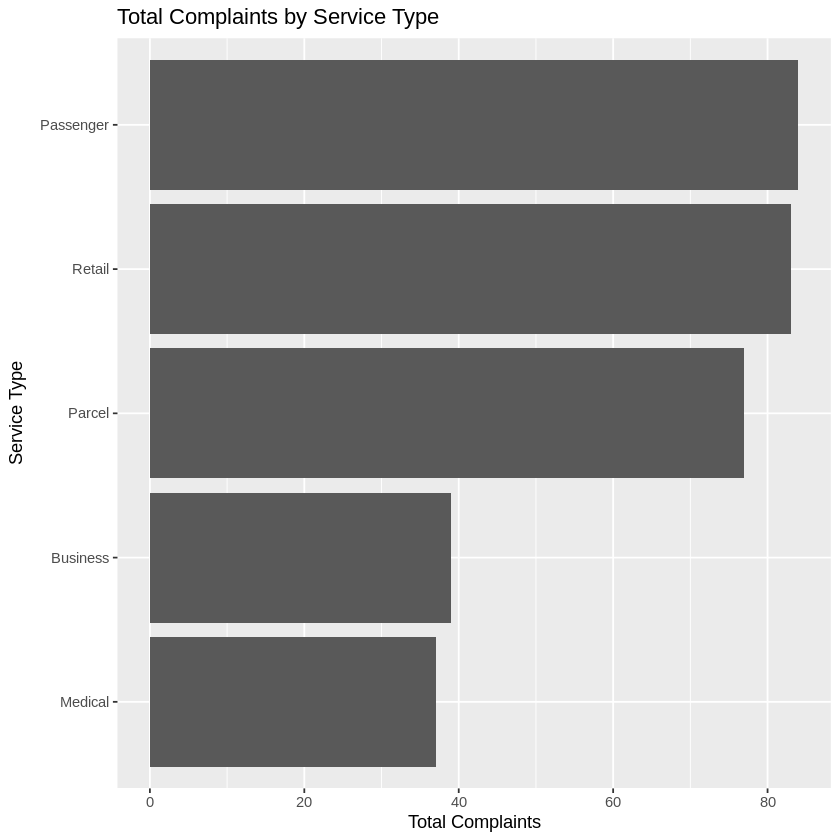

In [18]:
#Complaints by service type
complaints_service <- master %>%
  group_by(service_type) %>%
  summarise(total_complaints = sum(complaint_count, na.rm = TRUE)) %>%
  arrange(desc(total_complaints))

ggplot(complaints_service, aes(x = reorder(service_type, total_complaints), y = total_complaints)) +
  geom_bar(stat = "identity") +
  coord_flip() +
  labs(
    title = "Total Complaints by Service Type",
    x = "Service Type",
    y = "Total Complaints"
  )

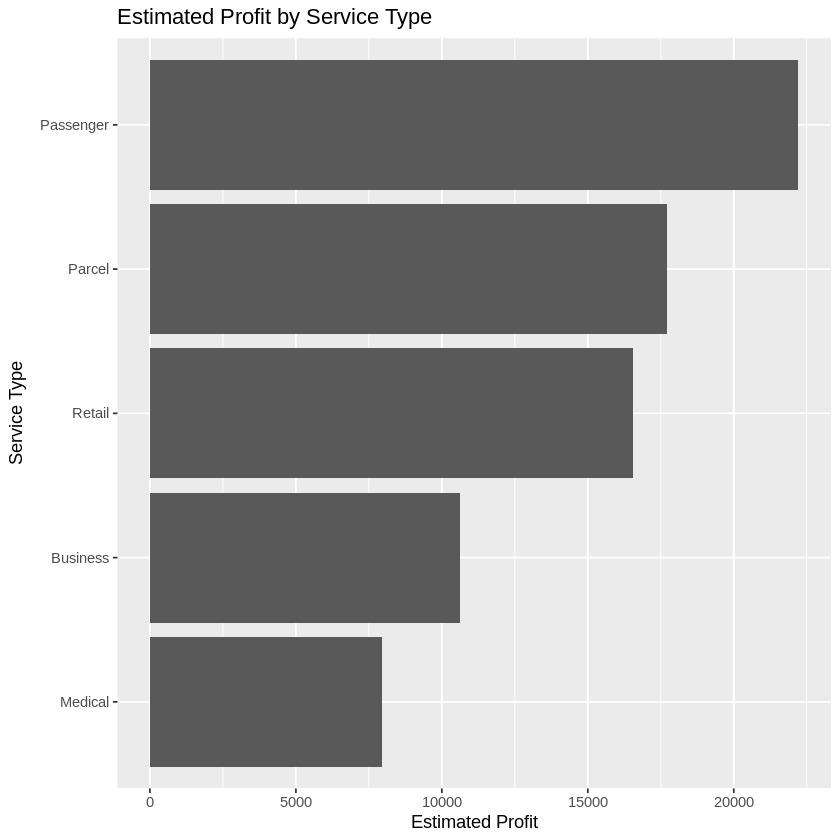

In [19]:
#Estimated profit by service type
profit_service <- master %>%
  group_by(service_type) %>%
  summarise(total_profit = sum(estimated_profit, na.rm = TRUE)) %>%
  arrange(total_profit)

ggplot(profit_service, aes(x = reorder(service_type, total_profit), y = total_profit)) +
  geom_bar(stat = "identity") +
  coord_flip() +
  labs(
    title = "Estimated Profit by Service Type",
    x = "Service Type",
    y = "Estimated Profit"
  )

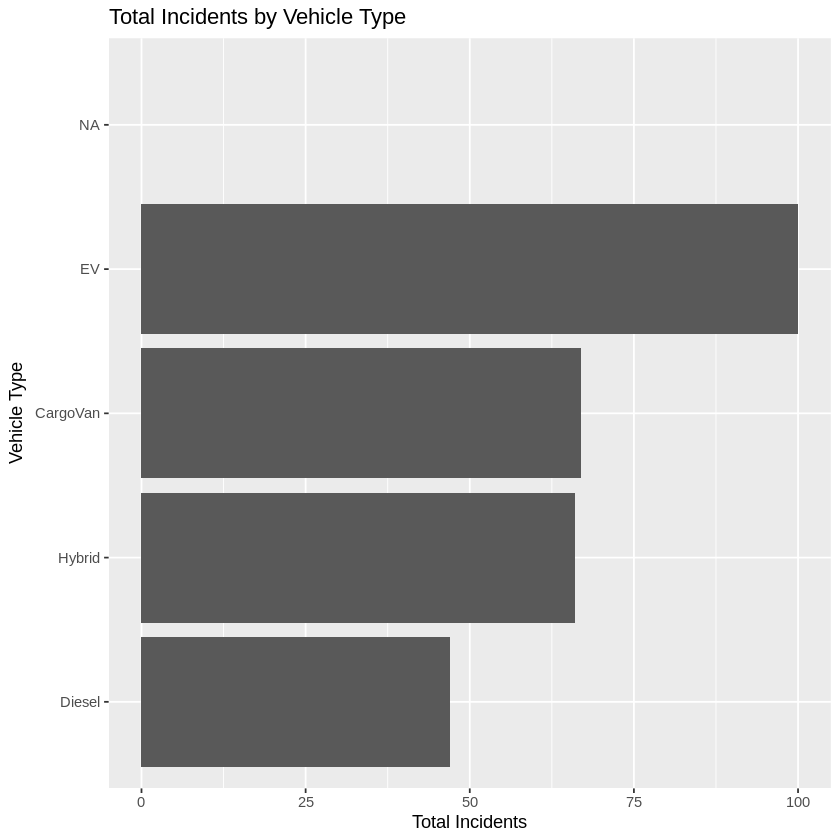

In [20]:
#Incidents by vehicle type
vehicle_incidents <- master %>%
  group_by(vehicle_type) %>%
  summarise(total_incidents = sum(incident_count, na.rm = TRUE)) %>%
  arrange(desc(total_incidents))

ggplot(vehicle_incidents, aes(x = reorder(vehicle_type, total_incidents), y = total_incidents)) +
  geom_bar(stat = "identity") +
  coord_flip() +
  labs(
    title = "Total Incidents by Vehicle Type",
    x = "Vehicle Type",
    y = "Total Incidents"
  )